# MiBiPreT example: Ordination with Amersfoort data

Diagnostic plots for data analysis on microbial biodegredation at the contaminant Amersfoort site. Author: Alraune Zech

Data based on the PhD thesis of *Johan van Leeuwen*, 2021 'Biodegredation of mono- and polyaromatic hydrocarbons in a contaminated aquifer originating from a former Pintsch gas factory site' which is equivalent to the manuscript of van Leeuwen et al., 2022 'Anaerobic degradation of benzene and other aromatic hydrocarbons in a tar-derived plume: Nitrate versus iron reducing conditions', J. of Cont. Hydrol. The data was provided by Johan van Leeuwen.
  
## Background: Amersfoort contaminant site

Close to the train station in Amersfoort, the Netherlands, the subsurface is contaminated with organic hydrocarbons forming a NAPL. Contamination originates from decades of operating manufactured gas plant, which dumped tar by-products in waste lagoons. The tar is a DNAPL and has spread into the underlying shallow unconfined aquifer. Sample wells were installed to measure various characteristics of the subsurface. The raw data contains measurements on
* environmental conditions, such as pH, redox potential, concentrations of oxygen, nitrate, etc
* contaminant concentration such as BTEX, indene, indane, naphtalene and multiple other (typically cyclic) petroleum hydrocarbons
* metabolite concentration, i.e. byproducts of degredation processes of contaminant
* isotope measurments for specific contaminants and samples
* counts of genes (RNA/DNA) of mibrobiota that is know to perform biodegredation as well as functional enzymes know to be responsible for biodegredation

**Required packages**

In [1]:
import mibiscreen as mbs

/home/alraune/GitHub/MiBiPreT/mibiscreen/mibiscreen/analysis/reduction/transformation.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


## Data loading

In [2]:
file_path = './amersfoort.xlsx'

Load and standardize data of environmental quantities/chemicals

In [3]:
environment_raw,units = mbs.load_excel(file_path,
                                    sheet_name = 'environment',
                                    verbose = False)

environment,units = mbs.standardize(environment_raw,
                                reduce = True,
                                verbose=False)

________________________________________________________________
________________________________________________________________
________________________________________________________________


Load and standardize data of contaminants:

In [4]:
contaminants_raw,units = mbs.load_excel(file_path,
                                    sheet_name = 'contaminants',
                                    verbose = False)

contaminants,units = mbs.standardize(contaminants_raw,
                                  reduce = False,
                                  verbose = False)

mbs.total_contaminant_concentration(contaminants,
                                include = True,
                                verbose = False)

________________________________________________________________
________________________________________________________________
________________________________________________________________
Maybe data not in standardized format. Run 'standardize()' first.
_________________________________________________________________


1          9
2      13344
3       4337
4       5781
5      87452
6     150695
7      57598
8      59496
9       3699
10       734
11         9
12        40
13    102811
14     66182
15     45938
16     26463
17      7911
18      9922
19     18826
20     27114
21     25733
22     10167
23      2301
24      1137
25       113
26        83
27        27
28     14985
29     10376
30         9
31         9
32         9
33        13
Name: contaminants_concentration, dtype: int64

Load and standardize data of DNA related data:

In [5]:
###------------------------------------------------------------------------###
### Load and standardize data of contaminants
dna_raw,units = mbs.load_excel(file_path,
                           sheet_name = 'sequencing',
                           verbose = True)

dna,units = mbs.standardize(dna_raw,
                        reduce = False,
                        verbose = True)

 Running function 'load_excel()' on data file  ./amersfoort.xlsx
Unit of quantities:
-------------------
  sample_nr Total bacteria 16SRrna Benzene carboxylase NirS NarG BssA SRB  \
0       NaN                     nr                  nr   nr   nr       nr   

  BssA nitraat Peptococcus  
0           nr          nr  
________________________________________________________________
Loaded data as pandas DataFrame:
--------------------------------
     sample_nr Total bacteria 16SRrna Benzene carboxylase           NirS  \
0          NaN                     nr                  nr             nr   
1       323(9)          799641.666667                   0            NaN   
2    A036(7.8)            8539.945995                   0      726.22309   
3    A012(8.5)           34533.186153                   0    7182.000624   
4    A005(8.5)              1527.6979                   0    1367.031651   
5     A005(12)           86025.363483                   0   11366.224123   
6     A010(12)     

Merge both data frames into one for further analysis:

In [6]:
data = mbs.merge_data([environment,contaminants],clean = True)

## Unconstrained Analysis (PCA)
### Data pre-processing

Specification of variables to chose for ordination. We make sure that variables selected for analysis are in standard names.

In [7]:
variables_1 = mbs.standard_names(['total_contaminants'])
variables_2 = mbs.standard_names(['nitrate','pH','nitrite','sulfate','Redox','EC','DOC',"Mn2","Fe2"])

Extracting data of interest from data frame. All other quantities are removed, since only columns of interest should be passed to ordination analysis routines. 

In [8]:
data_ordination = mbs.extract_data(data,
                               name_list = variables_1 + variables_2,
                               keep_setting_data = True)

Cleaning data, i.e. remove all sites where measurements are missing for any of the quantities

In [9]:
data_filtered = mbs.filter_values(data_ordination, 
              replace_NaN = 'remove', 
              inplace = True,
              verbose = True)
data_filtered

Perform filtering of values since ordination requires all values to be numeric.
The sample row(s) have been removed since they contain NaN values: [19]


,aquifer,obs_well,depth,sample_nr,manganese2,contaminants_concentration,pH,DOC,nitrate,sulfate,redoxpot,nitrite,EC,iron2
0,2.0,1024,15-16,1024(16),0.01,9,6.4,1.5,102,6,78,0.51,563,0.03
1,2.0,1033,21-22,1033(22),0.34,9,7.1,2.4,39,0,-145,0.13,500,11.00
2,2.0,241,15-16,241(16),0.13,27,5.7,4.5,54,7,102,0.20,401,1.10
3,2.0,241,20-21,241(21),0.19,14985,6.3,4.8,180,0,-32,1.08,366,14.50
4,2.0,241,29-30,241(30),0.93,10376,6.2,6.5,84,0,-20,0.36,310,6.40
5,2.0,241,35-36,241(36),0.05,9,5.5,5.5,158,31,150,0.90,351,0.11
6,2.0,320,20-21,320(21),0.42,13,7.3,3.6,181,40,-131,1.14,834,4.30
7,2.0,323,20-21,323(21),0.28,9,7.0,1.4,68,12,-86,0.28,539,1.30
8,1.0,323,8-9,323(9),0.13,9,5.6,6.1,122,35,152,0.58,322,0.04
9,1.0,352,8-9,352(9),0.16,3699,5.3,3.5,123,24,180,1.09,229,0.04


### Data transformation

Concentrations of contaminants (`Sum GC`) is log-transformed (given that concentration vary over orders of magnitude) and then standardized.
Other data is only standardized.

In [10]:
data_transformed = mbs.transform_values(data_ordination,
                 name_list = variables_1,
                 how = 'log_scale',
                 inplace = True,
                 )

data_transformed = mbs.transform_values(data_ordination,
                  name_list = variables_1,
                  how = 'standardize',
                  inplace = True,
                  )

data_transformed = mbs.transform_values(data_ordination,
                  name_list = variables_2,
                  how = 'standardize',
                  inplace = True,
                )

### Ordination analysis by PCA

In [11]:
ordination_output = mbs.pca(data_ordination,
                        independent_variables = variables_1+variables_2,
                        verbose = True)

 Running function 'pca()' on data
Information about the success of the PCA:
----------------------------------------------------------------
Principle component 0 explains 32.14% of the total variance.
Principle component 1 explains 24.3% of the total variance.
Principle component 2 explains 14.19% of the total variance.
Principle component 3 explains 10.2% of the total variance.
Principle component 4 explains 7.79% of the total variance.
Principle component 5 explains 4.74% of the total variance.
Principle component 6 explains 3.43% of the total variance.
Principle component 7 explains 2.34% of the total variance.
Principle component 8 explains 0.6% of the total variance.
Principle component 9 explains 0.28% of the total variance.

The correlation coefficient between PC1 and PC2 is -2.49e-16.
----------------------------------------------------------------


### Ordination plot

Figure saved to file:
 ordination_amersfoort_pca.png


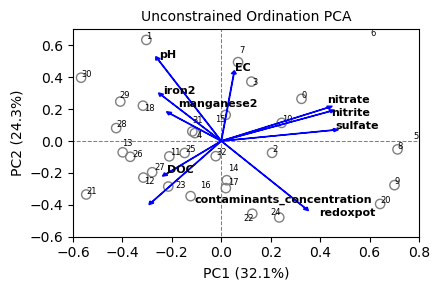

In [61]:
fig, ax = mbs.ordination_plot(ordination_output=ordination_output,
                plot_scores = True, 
                plot_loadings = True,
                rescale_loadings_scores = True,
                figsize = [4.5,3],
                title = "Unconstrained Ordination PCA",                
                axis_ranges = [-0.6,0.8,-0.6,0.7],
                label_fontsize = 10,
                loading_fontsize = 8,
                #score_fontsize = 6,
                #save_fig = 'ordination_amersfoort_pca.png',
                )

### Interpretation

The figure shows the results of the PCA (principle component analysis) as multi-variate statistics tool for the geochemical parameters. The axes denote the percentage of variance explained by each principal component. Data was standardized, with `Sum GC` (being the total sum of contaminants) being logarithmically transformed as via $log(x+1)$.

This biplot shows two different elements of information: the variable loadings show as arrows and the site scores shown as dots. The two plot axis represent the two main axis identified by the ordination methods. They are scales to the minimal value of $-1$ and the maximum value of $1$. 

The direction of the arrow indicates to which ordination axis it correlates. The length of the vector is equivalent to the extent of that correlation. Positive scores or loadings indicate positive correlation with the axis, where negative values indicate negative 
correlation. For example, a variable with negative loadings for the first two ordination axes is anticorrelated with the two largest trends in the data. Arrows pointing in the same direction indicate that the variable are correlated. Arrows at an right angle to one another are uncorrelated. Arrows that point in opposite directions are anti-correlated. A vector very close to the origin shows little to no correlation with the axes. 

Proximity of the site scores in the plot indicate the similarity between the sample sites. 

## Constrained Analysis (CCA & RDA)
### Data preprocessing

Specify groups of quantities to perform analysis on:
* group of geochemical parameters
* group of contaminants
* sequencing data

In [34]:
geochemicals_group = ['nitrate','sulfate','redoxpot','iron2','manganese2']
#contaminant_group = ['benzene','toluene','ethylbenzene','pm_xylene','indene','naphthalene']
contaminant_group = ['benzene','toluene','indene','naphthalene']
variables_dna = ['Total bacteria 16SRrna', 'Benzene carboxylase', 'NirS', 'NarG', 'BssA SRB',
                 'BssA nitraat', 'Peptococcus']

Extract data of quantities of interest:
*geochemical
*contaminants

In [35]:
geochem_selected = environment[['sample_nr']+geochemicals_group]
cont_selected = contaminants[['sample_nr']+contaminant_group]

contaminant_group_analysis = list(cont_selected.columns)
contaminant_group_analysis.remove('sample_nr')

Concatenate all relevant data:

In [36]:
data_ordination = mbs.merge_data([geochem_selected,cont_selected,dna],clean = True)


### Data transformation for CCA

In [43]:
data_cca = data_ordination.copy()

mbs.filter_values(data_cca,
              replace_NaN = 'remove',#'average',  # #'zero'
              inplace = True,
              #verbose = True
                 )

mbs.transform_values(data_cca,
                 name_list = variables_dna,
                 how = 'log_scale',
                 inplace = True,
                 )

,sample_nr,nitrate,sulfate,redoxpot,iron2,manganese2,benzene,toluene,indene,naphthalene,Total bacteria 16SRrna,Benzene carboxylase,NirS,NarG,BssA SRB,BssA nitraat,Peptococcus
2,241(16),54,7,102,1.10,0.13,3,7,3,13,4.034983,0.000000,3.721385,3.357466,5.252401,0.000000,0.000000
4,241(30),84,0,-20,6.40,0.93,5800,95,992,1450,4.641740,2.348511,3.480648,3.496423,5.617724,3.589096,2.054665
5,241(36),158,31,150,0.11,0.05,0,7,0,0,3.830129,0.000000,3.221866,3.674056,5.443256,0.000000,0.000000
6,320(21),181,40,-131,4.30,0.42,2,11,0,0,3.078475,0.000000,2.764814,2.582070,4.278219,0.000000,0.000000
13,4031(30),27,0,-62,7.70,0.76,8150,11667,3636,7887,4.491402,1.324699,1.903086,2.816676,5.028733,1.961916,3.024874
14,A003(10.8),72,8,8,0.84,0.14,22556,12690,3773,6652,4.510477,0.359311,4.388052,4.265633,5.545071,4.923110,0.000000
16,A005(12),5,8,93,0.66,0.34,1007,21280,6266,23870,4.934632,0.000000,4.055654,4.755325,6.922789,0.000000,0.000000
17,A005(22),37,3,153,0.82,0.41,847,7654,3008,5742,5.125004,0.000000,4.801324,5.219400,6.367878,4.877699,0.000000
18,A005(31),67,0,-92,9.10,1.20,2153,829,1284,1804,4.196119,1.529754,2.633278,2.798501,4.951141,2.344758,2.780089
20,A005(8.5),180,9,210,0.08,0.02,12,236,396,2726,3.184322,0.000000,3.136096,3.348162,4.533288,4.088889,0.000000


### Ordination analysis by CCA

In [45]:
cca_output = mbs.cca(data_cca,
                  independent_variables = contaminant_group_analysis,
                  dependent_variables = variables_dna,
                  verbose = True)

 Running function 'cca()' on data


### plot results CCA

Figure saved to file:
 cca_dna.png


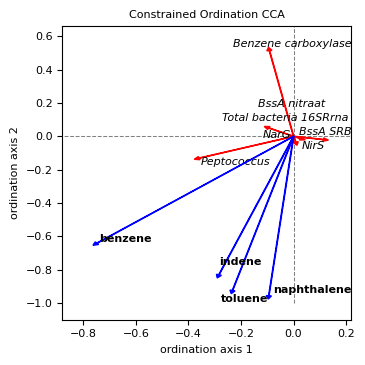

In [46]:
fig, ax = mbs.ordination_plot(ordination_output=cca_output,
                plot_scores = False,
                plot_loadings = True,
                rescale_loadings_scores = False,
                label_fontsize = 10,
                loading_fontsize = 8,
                score_fontsize = 6,
                title ="Constrained Ordination CCA",
                save_fig = 'cca_dna.png',
                )

### Data transformation for RDA

In [40]:
data_rda = data_ordination.copy()

mbs.filter_values(data_rda,
              replace_NaN = 'zero',
              # replace_NaN = 'average',
              # replace_NaN = 'remove',
              inplace = True,
              verbose = True)

### if (part of) data is log-transformed (before standardization):
mbs.transform_values(data_rda,
                  name_list = variables_dna,
                  how = 'log_scale',
                  inplace = True,
                  )

mbs.transform_values(data_rda,
                  how = 'standardize',
                  inplace = True,
                  )


Perform filtering of values since ordination requires all values to be numeric.
The values of the empty cells have been set to zero (0.0)


,sample_nr,nitrate,sulfate,redoxpot,iron2,manganese2,benzene,toluene,indene,naphthalene,Total bacteria 16SRrna,Benzene carboxylase,NirS,NarG,BssA SRB,BssA nitraat,Peptococcus
0,1024(16),0.734750,-0.191145,0.589483,-0.869397,-0.428803,-0.633485,-0.551406,-0.759306,-0.630936,-0.588809,0.101422,-1.291146,-2.952477,-1.679437,-1.387615,-0.683267
1,1033(22),-0.334960,-0.739649,-1.603644,1.895519,-0.299270,-0.633485,-0.551406,-0.759306,-0.630936,0.649000,-0.653388,-1.291146,0.669711,0.073910,0.338679,-0.683267
2,241(16),-0.080267,-0.099728,0.825515,-0.599711,-0.381700,-0.633105,-0.551406,-0.757848,-0.629336,-0.246418,-0.653388,0.763045,-0.278468,0.507445,-1.387615,-0.683267
3,241(21),2.059152,-0.739649,-0.492329,2.777671,-0.358149,0.324355,-0.536062,-0.306277,-0.332202,-0.192718,1.439754,-1.291146,-0.138085,-1.679437,-1.387615,-0.683267
4,241(30),0.429119,-0.739649,-0.374313,0.736119,-0.067681,0.102339,-0.539562,-0.277112,-0.452385,0.245151,1.849788,0.630160,-0.167797,0.659550,0.483128,0.889976
5,241(36),1.685603,2.094287,1.297578,-0.849233,-0.413102,-0.633485,-0.551406,-0.759306,-0.630936,-0.412382,-0.653388,0.487313,-0.026324,0.586909,-1.387615,-0.683267
6,320(21),2.076132,2.917043,-1.465959,0.206828,-0.267868,-0.633232,-0.550867,-0.759306,-0.630936,-1.021339,-0.653388,0.235022,-0.896021,0.101836,-1.387615,-0.683267
7,323(21),0.157446,0.357359,-1.023400,-0.549302,-0.322821,-0.633485,-0.551406,-0.759306,-0.630936,0.580988,-0.653388,-1.291146,0.891191,-1.679437,0.336832,-0.683267
8,323(9),1.074340,2.459956,1.317247,-0.866877,-0.381700,-0.633485,-0.551406,-0.759306,-0.630936,1.266885,-0.653388,-1.291146,1.449589,-1.679437,0.885856,-0.683267
9,352(9),1.091320,1.454366,1.592617,-0.866877,-0.369924,-0.629679,-0.524487,-0.682505,-0.444997,0.144795,-0.653388,-1.291146,0.949634,-0.017945,0.840615,-0.683267


### Ordination analysis by RDA

In [47]:
rda_output = mbs.rda(data_rda,
                  independent_variables = contaminant_group_analysis,
                  # independent_variables = contaminant_group_analysis + geochemicals_group,
                  dependent_variables = variables_dna,
                  verbose = True)


 Running function 'rda()' on data


### plot results RDA

Figure saved to file:
 ordination_amersfoort_rda.png


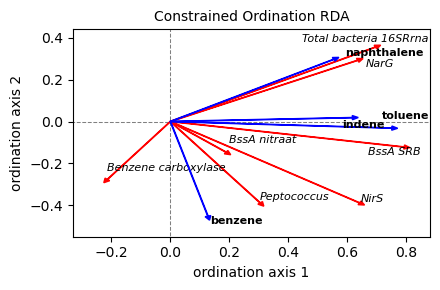

In [59]:
fig, ax = mbs.ordination_plot(ordination_output=rda_output,
                plot_scores = False,
                plot_loadings = True,
                rescale_loadings_scores = False,
                title = "Constrained Ordination RDA",
                figsize = [4.5,3],
                label_fontsize = 10,
                loading_fontsize = 8,
                #score_fontsize = 6,
                # axis_ranges = [-0.6,0.8,-0.8,1.0],
                save_fig = 'ordination_amersfoort_rda.png',
                )